# Scaling Python with Dask

In this lab exercise, we will explore how **Dask** (https://www.dask.org/) allows us to scale Python code from a single core to a massive parallel cluster, and how it handles datasets that are too large to fit into your computer's RAM.

### Learning Objectives:
1. **Setting up a Local Cluster:** Monitoring your computation in real-time.
2. **Dask Delayed:** Understanding lazy evaluation and task graphs.
3. **Dask DataFrames:** Parallelizing Pandas operations on synthetic, large-scale data.
4. **Dask Arrays & Moving Averages:** Using `map_overlap` to safely run windowed NumPy operations on chunked out-of-core data.

## Step 1: Prerequisites & Imports

In [1]:
import time
import os
import numpy as np
import pandas as pd
import dask
import dask.dataframe as dd
import dask.array as da
import matplotlib.pyplot as plt
from dask.distributed import Client, LocalCluster

print("Dask version:", dask.__version__)

Dask version: 2025.10.0


## Step 2: Setting up the Dask Distributed Client

When configuring a Dask LocalCluster, you are defining how your machine’s physical hardware (CPU and RAM) is partitioned to handle parallel processing.

The three main settings you adjust are **n_workers**, **threads_per_worker**, and **memory_limit**. Together, they dictate the blueprint of your parallel engine.

1. **What is a Worker (n_workers)?**
    A Worker is an independent Python process running on your machine. Think of it as an entirely separate instance of Python running in the background.

    How it works: Because each worker is a distinct process, it has its own dedicated chunk of your computer’s memory (RAM) and its own process ID (PID).

    The Benefit: Having multiple workers allows Dask to completely bypass Python’s Global Interpreter Lock (GIL). The GIL prevents a single Python process from running multiple lines of Python code at the exact same millisecond. By spawning multiple workers (processes), Dask bypasses this restriction entirely.

2. **What are Threads per Worker (threads_per_worker)?**
    A Thread is a sub-division of execution inside a worker process. If a Worker is a factory, Threads are the individual assembly lines inside that specific factory.

    How it works: All threads inside a single worker share the exact same memory space allocated to that worker.

    The Benefit: Because they share memory, threads can pass data between each other instantly with zero overhead. They don't need to serialize data or send it over local network sockets.


### Option A: High Workers, Low Threads
```Python
cluster = LocalCluster(n_workers=4, threads_per_worker=1)
```

**What this means:** You spin up 4 completely independent Python factories, each with 1 assembly line.

**When to use it:** Use this when your code relies heavily on pure Python (like standard loops, text parsing, or custom dictionaries). Pure Python triggers the GIL. By giving each core its own process, they never compete for the GIL.

**The Downside:** High memory overhead. Each worker has to load its own copy of the Python interpreter, Dask libraries, and metadata.

### Option B: Low Workers, High Threads
```Python
cluster = LocalCluster(n_workers=1, threads_per_worker=4)
```

**What this means:** You spin up 1 massive Python factory that contains 4 parallel assembly lines sharing the same room.

**When to use it:** Use this when your workload relies heavily on NumPy, Pandas, or Scikit-Learn. These libraries are written in C/Cython and release the GIL during heavy mathematical calculations. This allows multiple threads to run truly in parallel inside a single process.

**The Benefit:** Incredibly memory efficient. Data is shared between threads instantly without needing to be copied.

In [2]:
cluster = LocalCluster(n_workers=2, threads_per_worker=2, memory_limit='4GB')
# cluster = LocalCluster(n_workers=8,
#                        threads_per_worker=4,
#                        memory_limit='4GB')

client = Client(cluster)
client

#if you change settings, you will have to close dask first:
# client.close()
# cluster.close()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 7.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46317,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36753,Total threads: 2
Dashboard: http://127.0.0.1:45633/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:38919,


2026-06-23 12:15:16,589 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/bodo/miniconda3/envs/geodata/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/bodo/miniconda3/envs/geodata/lib/python3.12/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/bodo/miniconda3/envs/geodata/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exc

In [19]:
# client.close()
# cluster.close()

## Step 3: Understanding "Lazy Evaluation" with Dask Delayed

In [3]:
def inc(x):
    time.sleep(1)
    return x + 1

def add(x, y):
    time.sleep(1)
    return x + y

In [4]:
%%time
x = inc(1)
y = inc(2)
z = add(x, y)
print(f"Sequential Result: {z}")

Sequential Result: 5
CPU times: user 73 ms, sys: 15.2 ms, total: 88.2 ms
Wall time: 3 s


In [5]:
%%time
lazy_x = dask.delayed(inc)(1)
lazy_y = dask.delayed(inc)(2)
lazy_z = dask.delayed(add)(lazy_x, lazy_y)
print(f"Lazy Object: {lazy_z}")

Lazy Object: Delayed('add-e435aa5c-1b5e-4090-8f67-204bf8453b76')
CPU times: user 513 μs, sys: 62 μs, total: 575 μs
Wall time: 522 μs


## Step 4: Visualizing the Task Graph

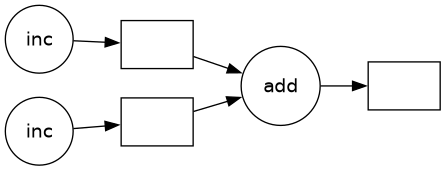

In [6]:
lazy_z.visualize(rankdir='LR')

## Step 5: Executing the Graph

In [6]:
%%time
final_result = lazy_z.compute()
print(f"Computed Result: {final_result}")

Computed Result: 5
CPU times: user 63.7 ms, sys: 12.4 ms, total: 76.1 ms
Wall time: 2.01 s


## Step 6: Scaling Up to DataFrames (Generating Synthetic Data)

In [7]:
os.makedirs('synthetic_data', exist_ok=True)
print("Generating synthetic CSV files...")
for i in range(10):
    records = 100_000
    df = pd.DataFrame({
        'station_id': np.random.randint(1000, 9999, size=records),
        'mean_temperature': np.random.uniform(-5, 45.0, size=records),
        'continent': np.random.choice(['SouthAmerica', 'NorthAmerica', 'Europa', 'Africa', 'Australia', 'Asia'], size=records)
    })
    df.to_csv(f'synthetic_data/climatedata_{i}.csv', index=False)
print("Data generation complete!")

Generating synthetic CSV files...
Data generation complete!


In [9]:
df

,station_id,mean_temperature,continent
0,9669,14.203703,Asia
1,9357,11.901390,Africa
2,3869,-2.534794,Australia
3,2318,37.583120,NorthAmerica
4,6229,13.739714,Asia
...,...,...,...
99995,5043,20.376327,Europa
99996,7685,23.084756,Australia
99997,6226,26.285225,Asia
99998,8426,20.996935,SouthAmerica


## Step 7: Reading Data with Dask vs Pandas

In [8]:
ddf = dd.read_csv('synthetic_data/climatedata_*.csv')
print(ddf)
print(f"\nNumber of partitions: {ddf.npartitions}")

Dask DataFrame Structure:
               station_id mean_temperature continent
npartitions=10                                      
                    int64          float64    string
                      ...              ...       ...
...                   ...              ...       ...
                      ...              ...       ...
                      ...              ...       ...
Dask Name: to_string_dtype, 2 expressions
Expr=ArrowStringConversion(frame=FromMapProjectable(b69ebe2))

Number of partitions: 10


## Step 8: Performing Parallel Data Manipulation

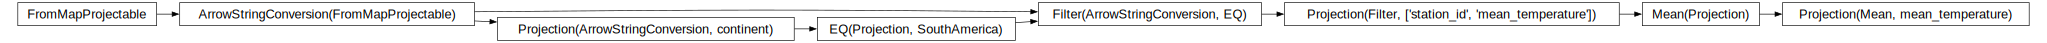

In [9]:
climatedata = ddf[ddf['continent'] == 'SouthAmerica']
grouped = climatedata.groupby('station_id')['mean_temperature'].mean()
grouped.visualize(rankdir='LR')

## Step 9: Triggering the Parallel Computation

In [10]:
%%time
result = grouped.compute()
print(result.head())

station_id
1000    17.828121
1001    20.451339
1002    19.073544
1003    18.684468
1005    23.934259
Name: mean_temperature, dtype: float64
CPU times: user 76.9 ms, sys: 7.89 ms, total: 84.8 ms
Wall time: 796 ms


## Step 10: Dask Arrays & Running Average on Climate Temperature Data

A standard `numpy.ndarray` requires contiguous memory allocation. A `dask.array` splits a massive array into grid-like arrangements of smaller arrays called **chunks**. 

Let's lazily create a high-frequency sensor signal modeling daily global temperature variations over an extended climate cycle (100 million data points split into 10 chunks).

In [11]:
total_elements = 100_000_000
chunk_size = 10_000_000

# Base climate cycle (e.g., Seasonal macro variations + local high frequency noise)
t = da.linspace(0, 50, total_elements, chunks=chunk_size)
base_temperature = 15 + 10 * da.sin(t)  # Shifts between 5 and 25 degrees Celsius
weather_noise = da.random.normal(0, 2.5, size=total_elements, chunks=chunk_size)
climate_dataset = base_temperature + weather_noise

print("Dask Climate Array structure:")
print(climate_dataset)

Dask Climate Array structure:
dask.array<add, shape=(100000000,), dtype=float64, chunksize=(10000000,), chunktype=numpy.ndarray>


## Step 11: Window Overlapping Calculations with `map_overlap`

In parallel computing with Dask, map_overlap is a specialized function used for chunked arrays when you need to perform "windowed" or "neighbor-dependent" operations.

To understand what it does, you first have to look at the problem it solves.

**The Problem:** Isolated Chunks
When Dask handles a massive array (like 100 gigabytes of climate temperature data), it splits that array into smaller, independent blocks called chunks. Each chunk is a standard NumPy array handled by a different CPU core or worker.

If you want to compute something simple like multiplying every number by 2, the workers don't need to talk to each other. They just process their own chunk in isolation.

However, if you want to calculate a moving average with a window size of 500, a worker processing the very beginning of Chunk 2 cannot do its job alone. It needs to know the last few data points from Chunk 1 to compute an accurate average for its boundaries. If chunks are strictly isolated, your calculation will either crash or produce incorrect, broken values at the edges of every block.

**The Solution:** What map_overlap Does
map_overlap solves this by temporarily adding "ghost zones" or padding to the edges of every chunk before running your function.

Here is exactly what happens step-by-step when you call map_overlap:

*Share Boundaries (The Overlap):* Dask looks at the depth parameter you provided (e.g., if your moving window is 500, the depth is 250). It instructs the workers to copy 250 elements from the end of Chunk 1 and paste them onto the beginning of Chunk 2. It does this across all neighboring boundaries.

*Grow the Chunks:* Temporarily, every chunk becomes slightly larger because it is now padded with data from its neighbors.

*Apply the Function:* Dask runs your standard NumPy function (like a moving average, a rolling standard deviation, or an image filter) on these padded chunks. Because of the padding, the function computes the edges flawlessly.

*Trim the Edges:* Once the calculation is complete, Dask automatically cuts off the temporary padding, restoring the chunks back to their original intended dimensions.

*Assemble the Result:* The perfectly calculated chunks are stitched back together into a continuous, seamless Dask array.

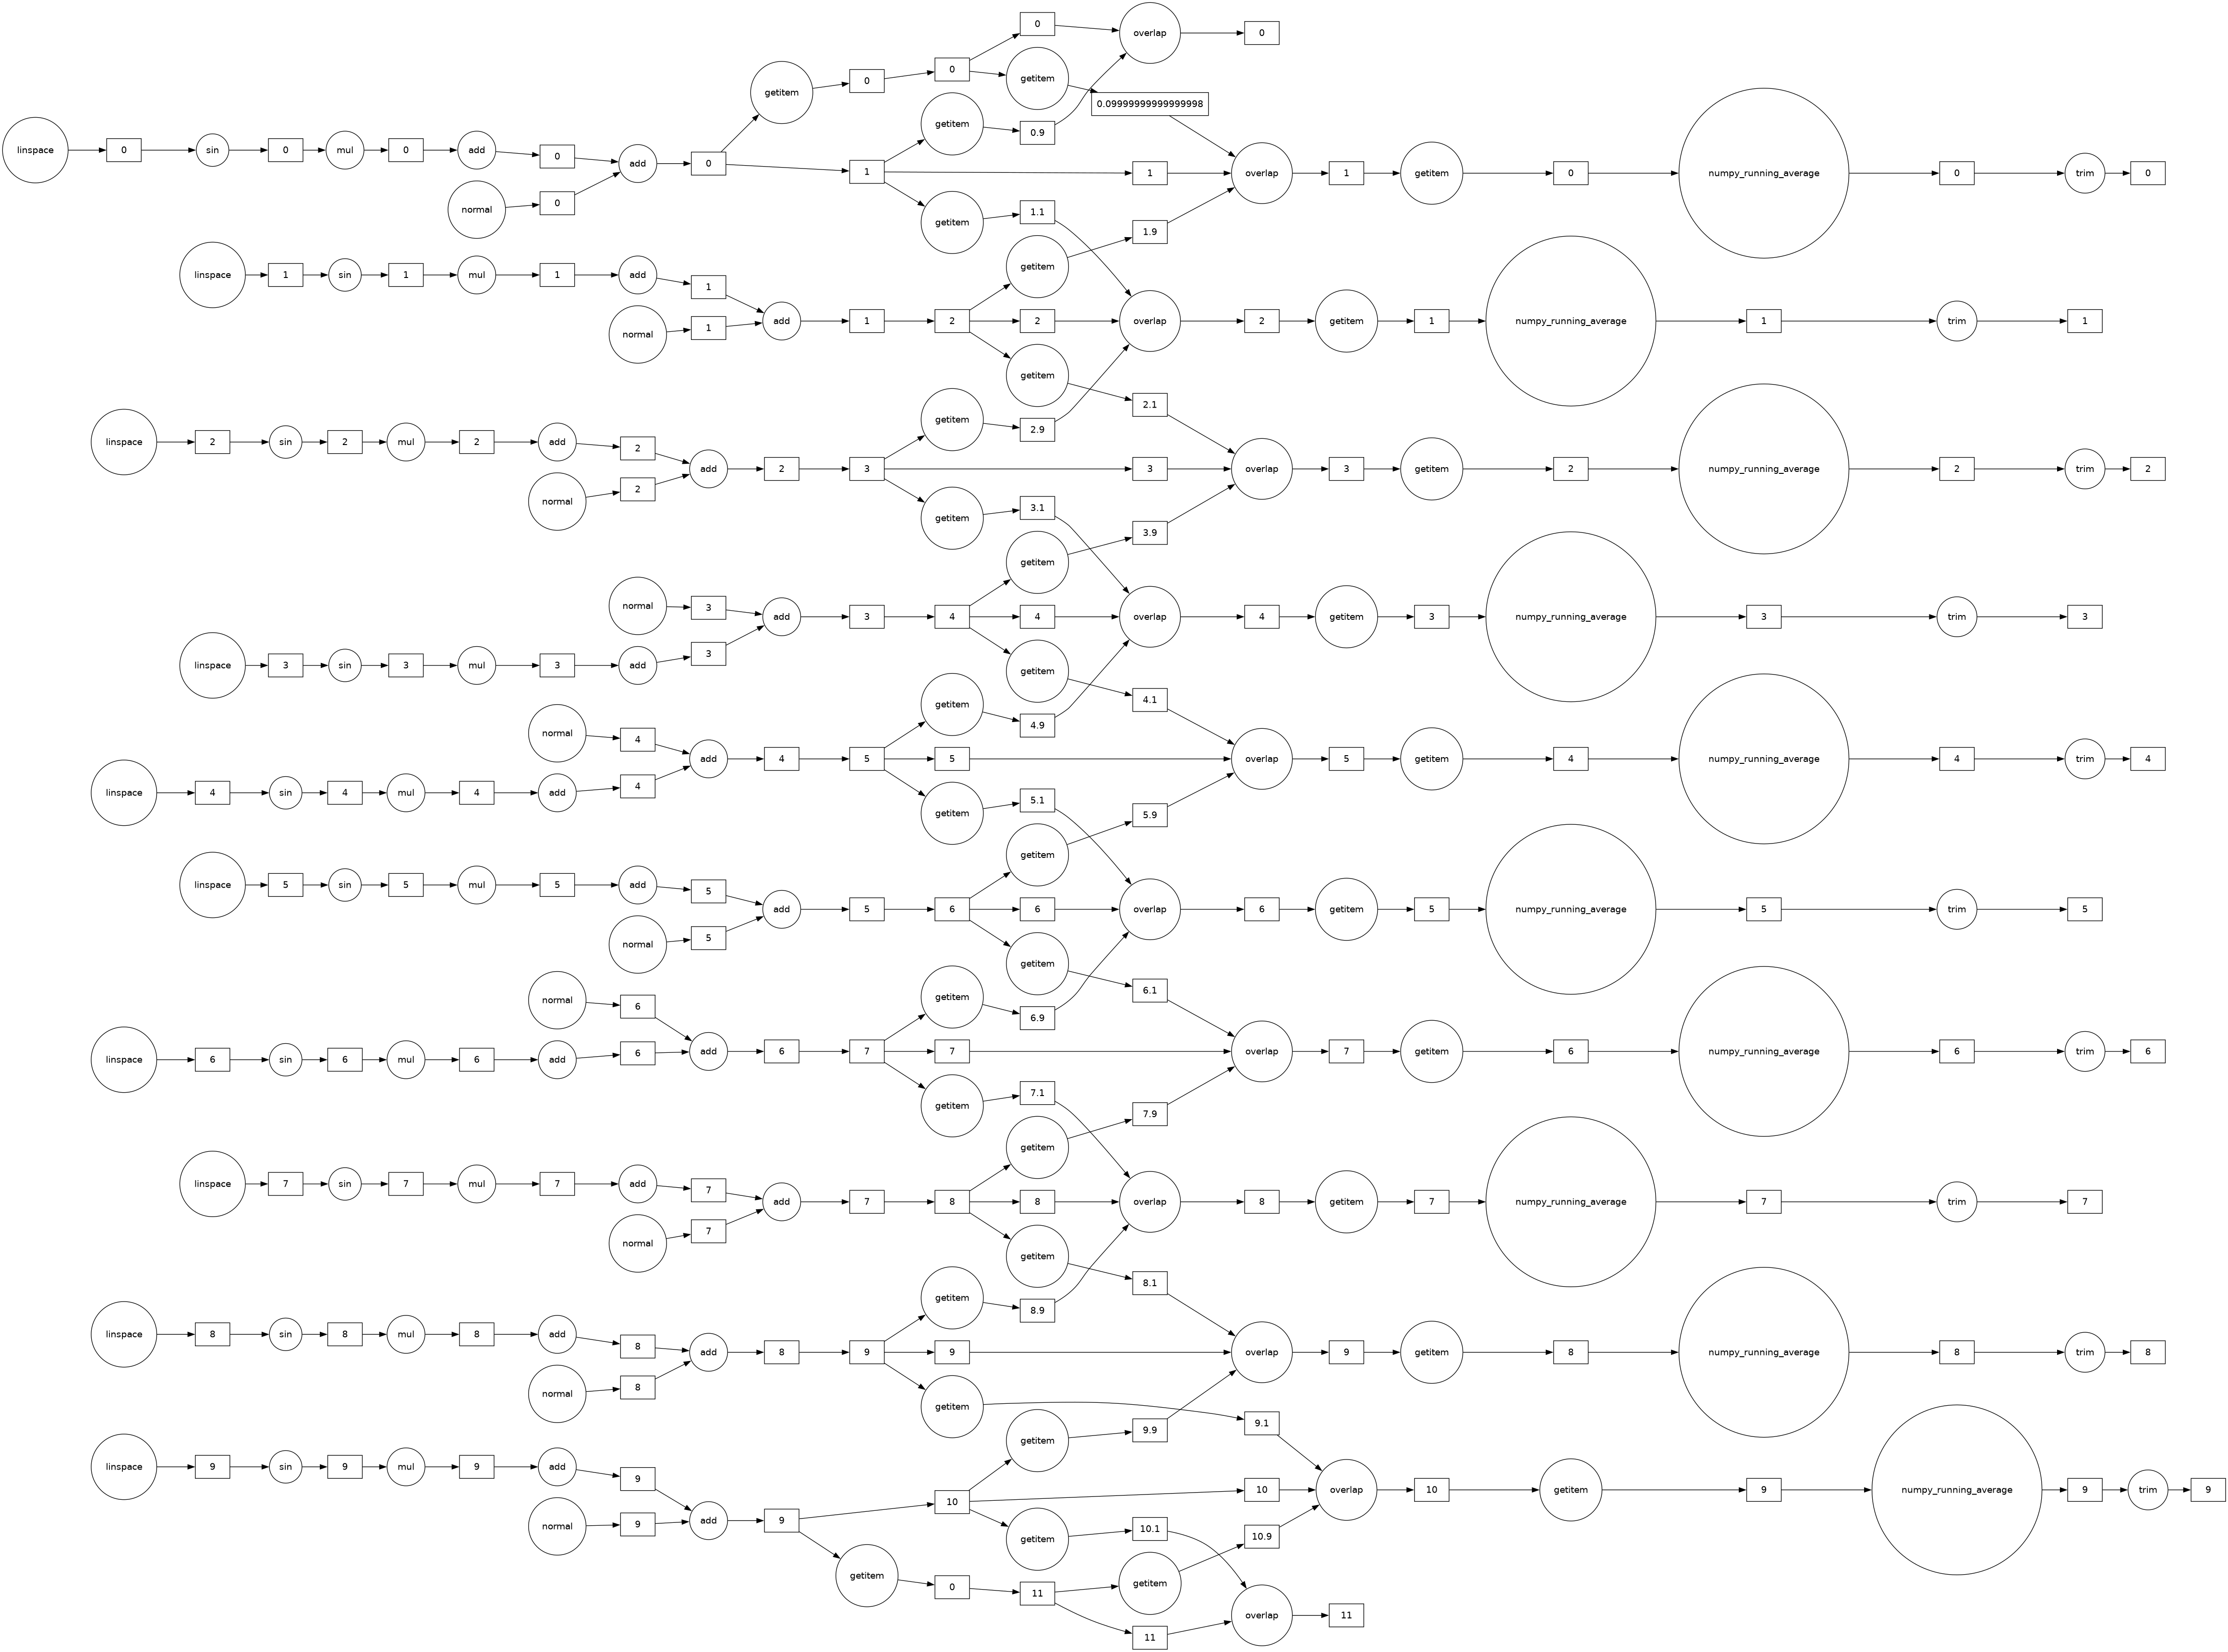

In [12]:
def numpy_running_average(chunk, window_size=500):
    window = np.ones(window_size) / window_size
    return np.convolve(chunk, window, mode='same')

window_length = 500
smoothed_climate = climate_dataset.map_overlap(
    numpy_running_average,
    depth=window_length // 2,
    boundary='reflect',
    window_size=window_length
)
smoothed_climate.visualize(rankdir='LR')

In [15]:
%%time
original_sample = climate_dataset[:5000].compute()
smoothed_sample = smoothed_climate[:5000].compute()

CPU times: user 42.7 ms, sys: 3.27 ms, total: 46 ms
Wall time: 1.09 s


## Step 12: Triggering the Out-of-Core Filter Pipeline

In [14]:
%%time
original_sample = climate_dataset.compute()
smoothed_sample = smoothed_climate.compute()

CPU times: user 442 ms, sys: 676 ms, total: 1.12 s
Wall time: 4.15 s


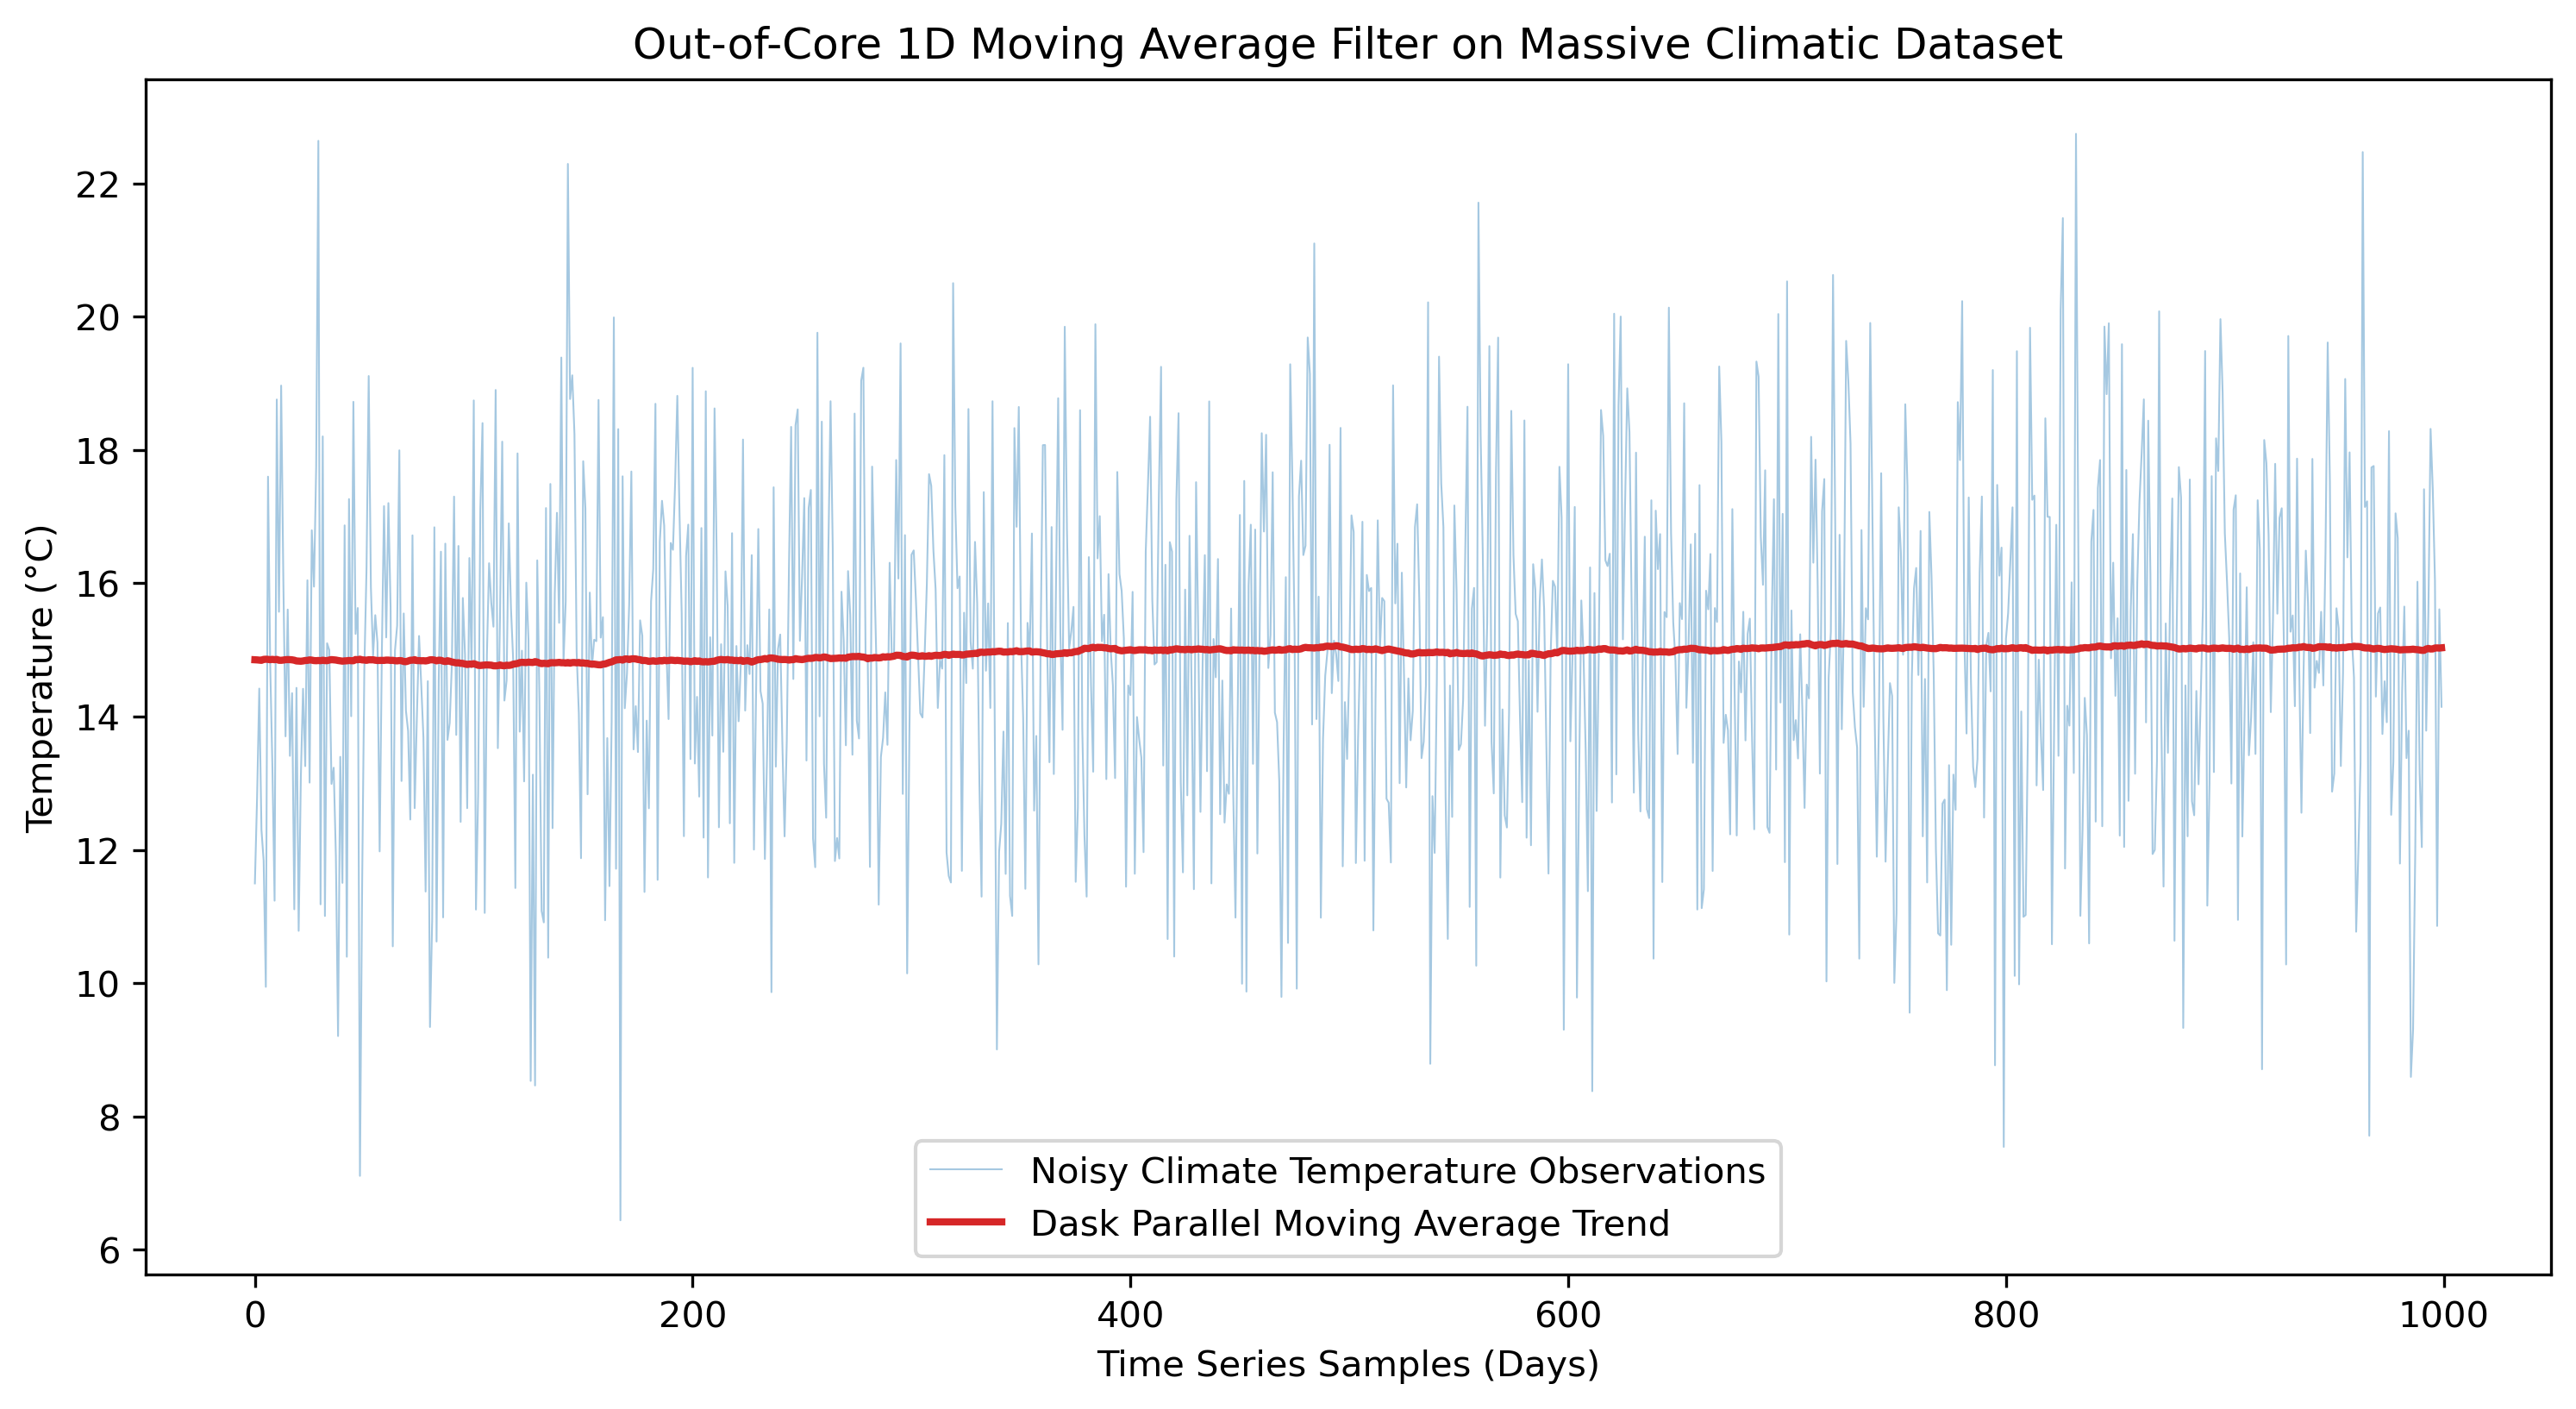

In [17]:
plt.figure(figsize=(12, 6), dpi=300)
plt.plot(original_sample[5000:6000], label='Noisy Climate Temperature Observations', lw=0.5, alpha=0.4, color='tab:blue')
plt.plot(smoothed_sample[5000:6000], label='Dask Parallel Moving Average Trend', color='tab:red', linewidth=2)
plt.title('Out-of-Core 1D Moving Average Filter on Massive Climatic Dataset')
plt.xlabel('Time Series Samples (Days)')
plt.ylabel('Temperature (°C)')
plt.legend()


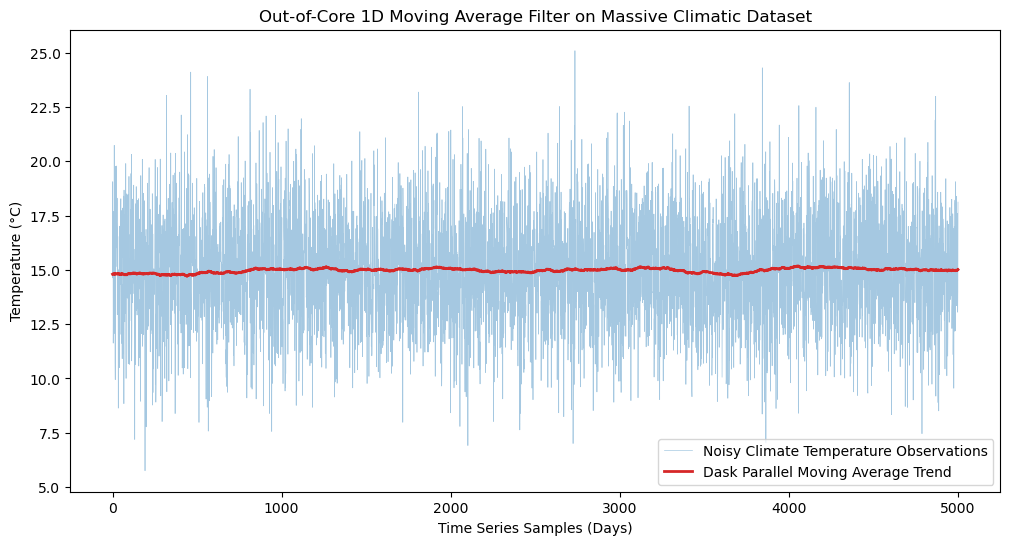

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(original_sample, label='Noisy Climate Temperature Observations', lw=0.5, alpha=0.4, color='tab:blue')
plt.plot(smoothed_sample, label='Dask Parallel Moving Average Trend', color='tab:red', linewidth=2)
plt.title('Out-of-Core 1D Moving Average Filter on Massive Climatic Dataset')
plt.xlabel('Time Series Samples (Days)')
plt.ylabel('Temperature (°C)')
plt.legend()

In [15]:
#re-run on full dataset (if not already done)
original_sample = climate_dataset.compute()
smoothed_sample = smoothed_climate.compute()

/home/bodo/miniconda3/envs/geodata/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


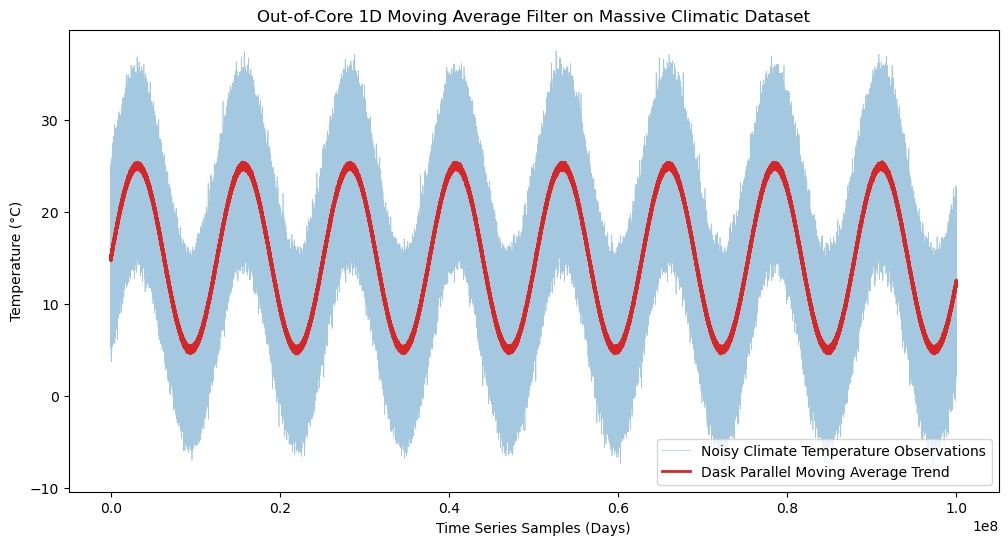

In [33]:
# Careful, this is really slow!
plt.figure(figsize=(12, 6))
plt.plot(original_sample, label='Noisy Climate Temperature Observations', lw=0.2, alpha=0.4, color='tab:blue')
plt.plot(smoothed_sample, label='Dask Parallel Moving Average Trend', color='tab:red', linewidth=2)
plt.title('Out-of-Core 1D Moving Average Filter on Massive Climatic Dataset')
plt.xlabel('Time Series Samples (Days)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

## Repeat running average exercise (numba/numpy)

Remember our previous version:
```python
    @njit(parallel=True)
def compute_rolling_median_parallel(data, window_size):
    n = len(data)
    output = np.zeros(n)
    
    # prange automatically distributes loop indexes across available CPU threads
    for i in prange(window_size, n):
        window = data[i - int(window_size/2):i + int(window_size/2)]
        output[i] = np.median(window)
    return output
```

In [4]:
# Generate a large synthetic time series (20 million elements)
# Simulating a random walk for stock prices or sensor readings
# with dask
da.random.seed(42)
n_samples = 20_000_000
raw_signals = da.cumsum(da.random.normal(0, 1, n_samples)) + 100

print(f"Generated time-series array with {n_samples:,} elements.")
print(f"Memory footprint: {raw_signals.nbytes / 1e6:.2f} MB")

Generated time-series array with 20,000,000 elements.
Memory footprint: 160.00 MB


In [5]:
# we can treat this as multiple chunks - here we use steps of 1e5 elements
raw_signals = raw_signals.rechunk(1e5)
raw_signals

dask.array<rechunk-merge, shape=(20000000,), dtype=float64, chunksize=(100000,), chunktype=numpy.ndarray>

In [6]:
raw_signals[0:10000]

dask.array<getitem, shape=(10000,), dtype=float64, chunksize=(10000,), chunktype=numpy.ndarray>

In [7]:
from scipy.ndimage import median_filter
pure_scipy = median_filter(raw_signals[0:10000], size=500)
pure_scipy.shape

(10000,)

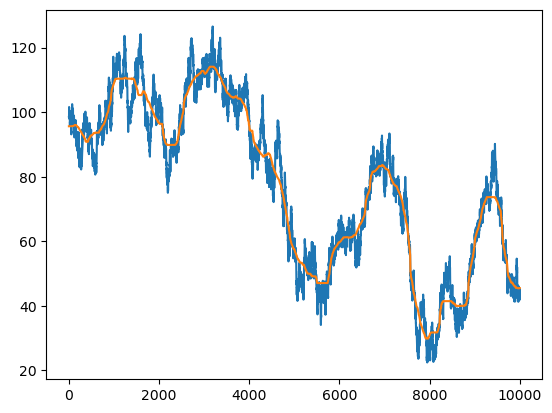

In [8]:
plt.plot(raw_signals[0:10000])
plt.plot(pure_scipy)

In [9]:
window_length = 500

smoothed_median_raw_signals= raw_signals.map_overlap(
    median_filter,
    depth=window_length // 2,
    boundary='reflect',
    size=window_length,
)

In [10]:
dask_median_results = smoothed_median_raw_signals.compute()

In [11]:
dask_median_results

array([  95.64561427,   95.64561427,   95.64561427, ..., -901.05340944,
       -901.05340944, -901.05340944])

In [13]:
dask_median_results.shape

(20000000,)

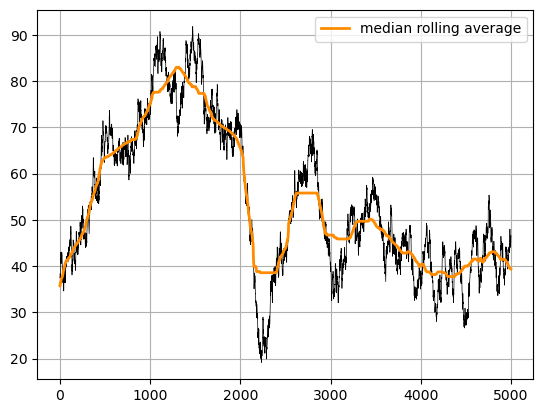

In [14]:
plt.plot(raw_signals[20000:25000], 'k-', lw=0.5)
plt.plot(dask_median_results[20000:25000], '-', lw=2, color='darkorange', label='median rolling average')
plt.grid()
plt.legend()

## Step 13: Cleaning Up Cluster Connections

In [15]:
client.close()
cluster.close()
print("Cluster safely shut down.")

Cluster safely shut down.
